>>> Wczytano wektor kwantowy (klucz 'phi') o kształcie (563, 15) oraz 563 etykiet.

>>> Start optymalizacji Walk-Forward (ElasticNet)...

--- WYNIKI ELASTICNET OOS (Threshold: 0.40) ---
Accuracy: 0.5538
AUC ROC:  0.5167

--- ZNACZENIE OSI POMIAROWYCH (TOP 5) ---
1. Q0_Sat_Z: 0.4499
2. Q2_Sat_Y: 0.4112
3. Q3_Sat_X: 0.3640
4. Q4_Sat_Z: 0.3052
5. Q4_Sat_Y: 0.2829


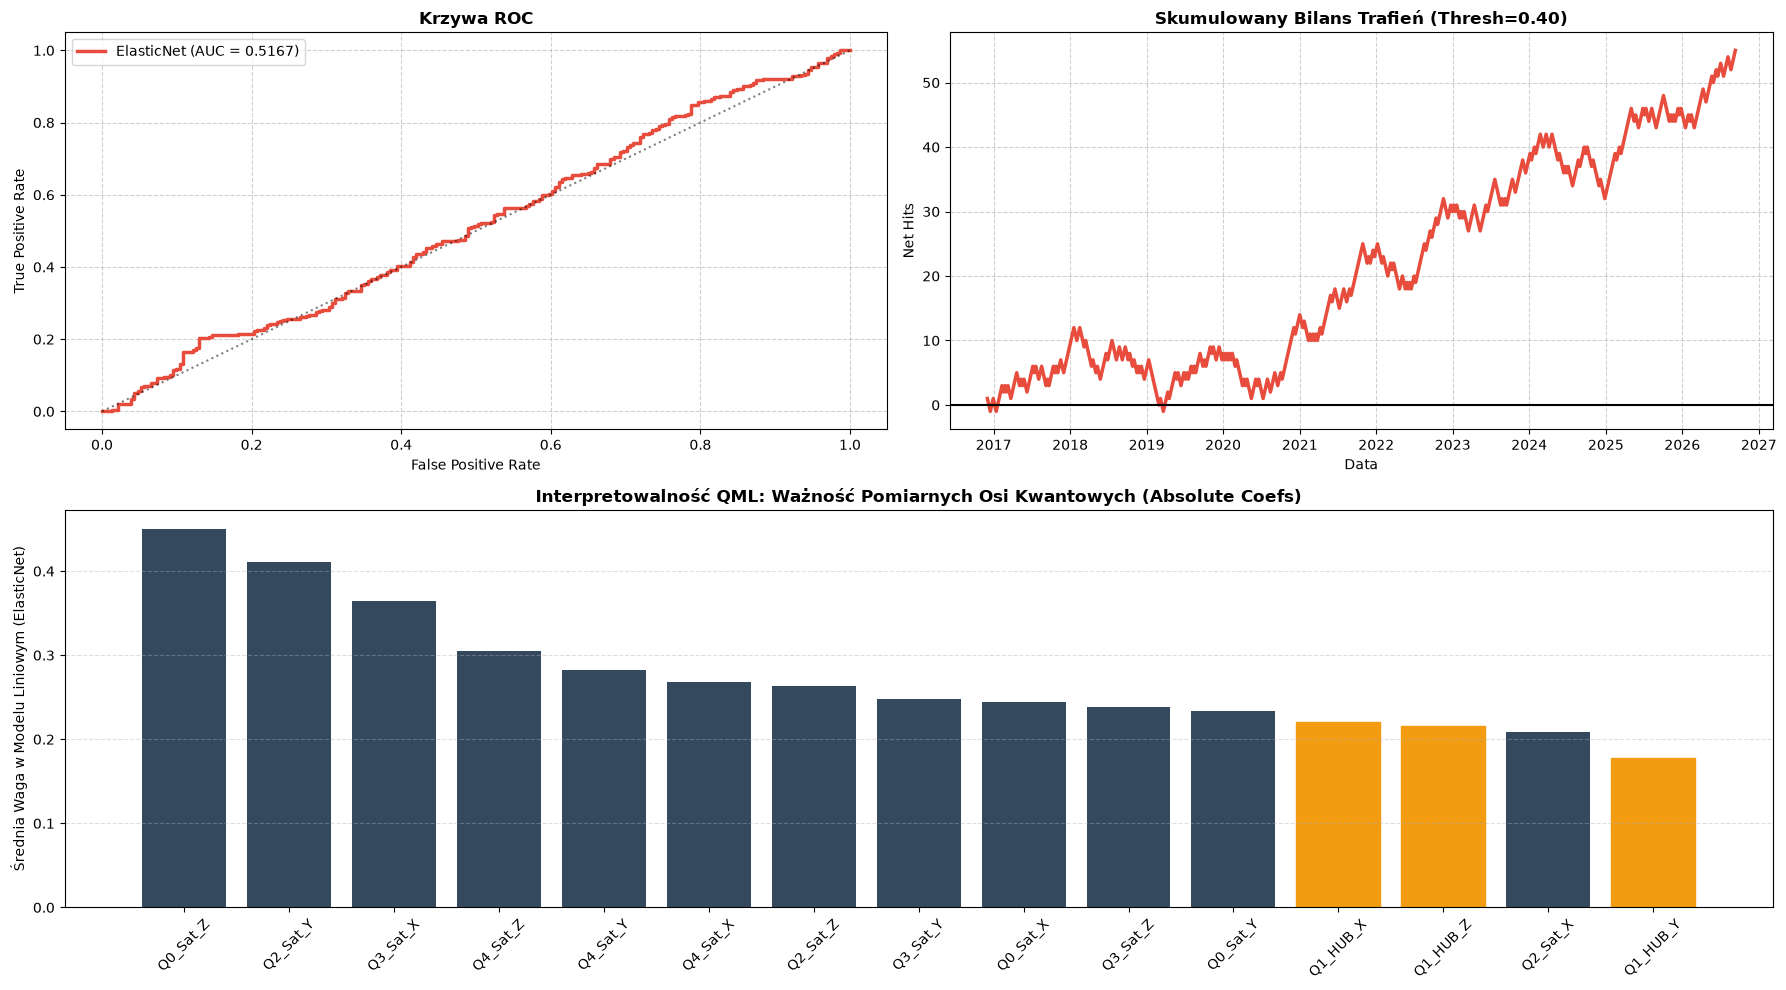

In [2]:
%matplotlib inline

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. KONFIGURACJA PLIKÓW I DANYCH
# ==========================================
# Prawidłowa nazwa Twojego pliku z dysku
PLIK_KACHE = "phi_odra_Top5_Rank1_Opt_q1_0.86_1.00_0.80_0.27_0.95.npz" 
csv_path = "dataset_final.csv" if os.path.exists("dataset_final.csv") else "dane/dataset_final.csv"

# Wczytanie etykiet (y) i dat
df = pd.read_csv(csv_path, index_col=0)
df.index = pd.to_datetime(df.index)
y_raw = df["target_y"].astype(int).values
dates_raw = df.index.values

LOOKBACK = 52
y = y_raw[LOOKBACK:]
dates = dates_raw[LOOKBACK:]

# Wczytanie 15-wymiarowej kwantowej przestrzeni cech z archiwum .npz
if not os.path.exists(PLIK_KACHE):
    raise FileNotFoundError(f"Nie znaleziono pliku {PLIK_KACHE}. Upewnij się, że jest w tym samym folderze co Twój notatnik.")

# Wczytujemy całe archiwum
loaded_archive = np.load(PLIK_KACHE, allow_pickle=True)

# Dynamicznie pobieramy pierwszy dostępny klucz w archiwum, żeby uniknąć błędu KeyError
first_key = loaded_archive.files[0]
Phi_real = loaded_archive[first_key]

print(f">>> Wczytano wektor kwantowy (klucz '{first_key}') o kształcie {Phi_real.shape} oraz {len(y)} etykiet.")

# Nazwy wymiarów do finalnej analizy i wykresu
FEATURE_NAMES = [
    "Q0_Sat_X", "Q0_Sat_Y", "Q0_Sat_Z",
    "Q1_HUB_X", "Q1_HUB_Y", "Q1_HUB_Z",
    "Q2_Sat_X", "Q2_Sat_Y", "Q2_Sat_Z",
    "Q3_Sat_X", "Q3_Sat_Y", "Q3_Sat_Z",
    "Q4_Sat_X", "Q4_Sat_Y", "Q4_Sat_Z"
]

# ==========================================
# 2. TRENOWANIE KROCZĄCE: LOGISTIC REGRESSION (ELASTICNET)
# ==========================================
print("\n>>> Start optymalizacji Walk-Forward (ElasticNet)...")

TRAIN_WINDOW = 52
inner_cv = TimeSeriesSplit(n_splits=3)

# Solver 'saga' jest wymagany do wsparcia kary elasticnet w sklearn
pipeline = Pipeline([
    ("scaler", StandardScaler()), 
    ("logreg", LogisticRegression(penalty="elasticnet", solver="saga", max_iter=2000, random_state=42))
])

# Siatka hiperparametrów:
# C: Siła regularyzacji (mniejsze C = silniejsza kara)
# l1_ratio: 0.0 (tylko L2/Ridge), 1.0 (tylko L1/Lasso - wygaszanie cech), wartości pośrednie to hybryda
param_grid = {
    "logreg__C": [0.01, 0.1, 1.0, 5.0],
    "logreg__l1_ratio": [0.1, 0.5, 0.9, 1.0] 
}

results = {"y_true": [], "dates": [], "prob": []}
feature_importances_history = []

for t in range(TRAIN_WINDOW, len(y)):
    X_tr, X_te = Phi_real[t - TRAIN_WINDOW : t], Phi_real[t : t + 1]
    y_tr = y[t - TRAIN_WINDOW : t]
    
    results["y_true"].append(y[t])
    results["dates"].append(dates[t])
    
    search = GridSearchCV(pipeline, param_grid, cv=inner_cv, scoring="roc_auc", n_jobs=-1)
    search.fit(X_tr, y_tr)
    
    best_model = search.best_estimator_
    results["prob"].append(best_model.predict_proba(X_te)[0, 1])
    
    # Wyciąganie wag z najlepszego modelu logistycznego dla danego okna
    coefs = best_model.named_steps["logreg"].coef_[0]
    feature_importances_history.append(coefs)

y_true = np.array(results["y_true"])
prob_preds = np.array(results["prob"])

# Optymalizacja progu
best_thresh, best_acc = 0.50, 0
for thresh in np.arange(0.40, 0.60, 0.01):
    acc = accuracy_score(y_true, (prob_preds > thresh).astype(int))
    if acc > best_acc: best_acc, best_thresh = acc, thresh

final_preds = (prob_preds > best_thresh).astype(int)

# ==========================================
# 3. ANALIZA WAŻNOŚCI CECH (OTWARCIE CZARNEJ SKRZYNKI)
# ==========================================
# Uśredniamy wartość bezwzględną współczynników ze wszystkich okien testowych
avg_coefs = np.mean(np.abs(feature_importances_history), axis=0)

# Sortowanie cech od najważniejszej do najmniej ważnej
sorted_idx = np.argsort(avg_coefs)[::-1]
sorted_features = [FEATURE_NAMES[i] for i in sorted_idx]
sorted_importances = avg_coefs[sorted_idx]

print(f"\n--- WYNIKI ELASTICNET OOS (Threshold: {best_thresh:.2f}) ---")
print(f"Accuracy: {best_acc:.4f}")
print(f"AUC ROC:  {roc_auc_score(y_true, prob_preds):.4f}")

print("\n--- ZNACZENIE OSI POMIAROWYCH (TOP 5) ---")
for i in range(5):
    print(f"{i+1}. {sorted_features[i]}: {sorted_importances[i]:.4f}")

# ==========================================
# 4. POTRÓJNA WIZUALIZACJA
# ==========================================
fig = plt.figure(figsize=(18, 10))
ax1 = plt.subplot(2, 2, 1)
ax2 = plt.subplot(2, 2, 2)
ax3 = plt.subplot(2, 1, 2)

# --- Wykres 1: ROC Curve ---
fpr, tpr, _ = roc_curve(y_true, prob_preds)
ax1.plot(fpr, tpr, color='#e74c3c', lw=2.5, label=f'ElasticNet (AUC = {roc_auc_score(y_true, prob_preds):.4f})')
ax1.plot([0, 1], [0, 1], 'k:', alpha=0.5)
ax1.set_title('Krzywa ROC', fontweight='bold')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# --- Wykres 2: Net Hits ---
net_hits = np.cumsum(np.where(final_preds == y_true, 1, -1))
ax2.plot(results["dates"], net_hits, color='#e74c3c', lw=2.5)
ax2.axhline(0, color='black', lw=1.5)
ax2.set_title(f'Skumulowany Bilans Trafień (Thresh={best_thresh:.2f})', fontweight='bold')
ax2.set_xlabel('Data')
ax2.set_ylabel('Net Hits')
ax2.grid(True, linestyle='--', alpha=0.6)

# --- Wykres 3: Quantum Feature Importance ---
bars = ax3.bar(sorted_features, sorted_importances, color='#34495e')
# Kolorowanie huba i satelitów dla przejrzystości
for i, bar in enumerate(bars):
    if "HUB" in sorted_features[i]:
        bar.set_color('#f39c12') # Wyróżnienie głównego huba (PEKAO) na pomarańczowo
        
ax3.set_title('Interpretowalność QML: Ważność Pomiarnych Osi Kwantowych (Absolute Coefs)', fontweight='bold')
ax3.set_ylabel('Średnia Waga w Modelu Liniowym (ElasticNet)')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(True, axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()